In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [4]:
df = pd.read_csv('data/steam_avg_data.csv')


In [80]:

df['is_successful'] = (df['avg_concurrent_players_after_90'] > 80).astype('float') 
features = [
    'estimated_launch_followers', 
    'price', 
    'is_vet_dev', 
    'is_singleplayer', 
    'review_score',
    'avg_sentiment',
    'is_q4_release',
    'is_sequel',
    'is_free'
]

X = df[features]
y = df['is_successful']

scaler = StandardScaler()
X = X.fillna(0)
X_train, X_test, y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)


X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=features)

model = LogisticRegression()
model.fit(X_train,y_train)

C:\Users\Akshay\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [77]:
y_pred = model.predict(X_test)
model.score(X_test,y_test)

0.7285714285714285

In [47]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       0.75      0.64      0.69        33
         1.0       0.71      0.81      0.76        37

    accuracy                           0.73        70
   macro avg       0.73      0.72      0.72        70
weighted avg       0.73      0.73      0.73        70



In [78]:
#geeks for geeks
coefficients = model.coef_[0]
odds_ratios = np.exp(coefficients)


feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coefficients,
    'Odds Ratio': odds_ratios
})
print("\nFeature Importance (Coefficient and Odds Ratio):")
print(feature_importance.sort_values(by='Coefficient', ascending=False))



Feature Importance (Coefficient and Odds Ratio):
                      Feature  Coefficient  Odds Ratio
2                  is_vet_dev     0.895216    2.447864
3             is_singleplayer     0.529498    1.698080
8                     is_free     0.336823    1.400491
5               avg_sentiment     0.195868    1.216367
7                   is_sequel     0.163192    1.177263
1                       price     0.032073    1.032593
0  estimated_launch_followers     0.000073    1.000073
4                review_score    -0.008770    0.991268
6               is_q4_release    -0.142454    0.867228


C:\Users\Akshay\AppData\Local\Temp\ipykernel_37520\638576279.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


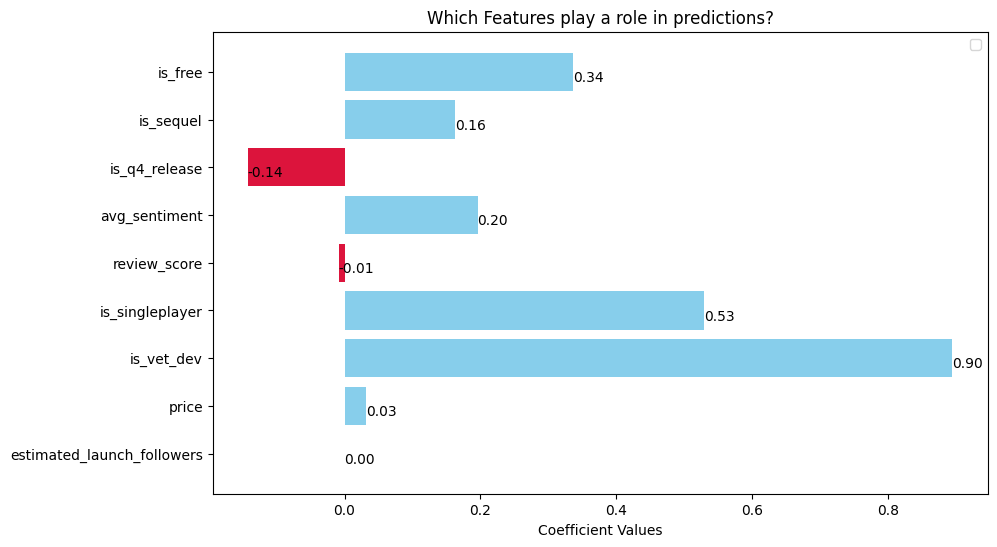

In [79]:
# plt.figure(feature_importance.Feature,feature_importance.Coefficient)

plt.figure(figsize=(10, 6))
bars = plt.barh(feature_importance.Feature, feature_importance.Coefficient,  color = np.where(feature_importance['Coefficient']<0,'crimson','skyblue'))
plt.xlabel('Coefficient Values')
plt.title('Which Features play a role in predictions?')
plt.legend()

# Add value labels
for bar in bars:
    plt.text(bar.get_width(), bar.get_y()+0.2, f'{bar.get_width():.2f}')

plt.show()

In [16]:
df['is_successful'] = (df['avg_concurrent_players_after_90'] > 0.02 * df['estimated_launch_followers']).astype('float')
features = [
    'estimated_launch_followers', 
    'price', 
    'is_vet_dev', 
    'is_singleplayer', 
    'review_score',
    'avg_sentiment',
    'is_q4_release',
    'is_sequel',
    'is_free'
]

X = df[features]
y = df['is_successful']

scaler = StandardScaler()
X = X.fillna(0)
X_train, X_test, y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)


X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=features)

model = LogisticRegression()
model.fit(X_train,y_train)

C:\Users\Akshay\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [17]:
y_pred = model.predict(X_test)
model.score(X_test,y_test)

0.6428571428571429

In [18]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00        25
         1.0       0.64      1.00      0.78        45

    accuracy                           0.64        70
   macro avg       0.32      0.50      0.39        70
weighted avg       0.41      0.64      0.50        70



C:\Users\Akshay\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Akshay\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Akshay\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_c

In [19]:
coefficients = model.coef_[0]
odds_ratios = np.exp(coefficients)


feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coefficients,
    'Odds Ratio': odds_ratios
})
print("\nFeature Importance (Coefficient and Odds Ratio):")
print(feature_importance.sort_values(by='Coefficient', ascending=False))


Feature Importance (Coefficient and Odds Ratio):
                      Feature  Coefficient  Odds Ratio
2                  is_vet_dev     0.586302    1.797330
5               avg_sentiment     0.505081    1.657120
3             is_singleplayer     0.394120    1.483079
8                     is_free     0.151867    1.164006
1                       price     0.019047    1.019230
6               is_q4_release     0.014577    1.014684
0  estimated_launch_followers     0.000027    1.000027
4                review_score    -0.001059    0.998942
7                   is_sequel    -0.012232    0.987843


C:\Users\Akshay\AppData\Local\Temp\ipykernel_30060\1094621142.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


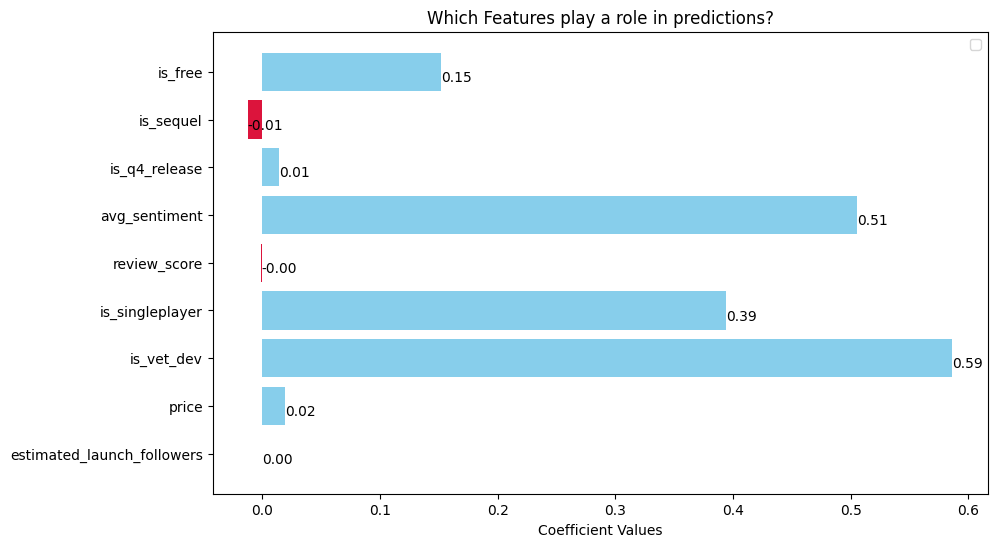

In [20]:
plt.figure(figsize=(10, 6))
bars = plt.barh(feature_importance.Feature, feature_importance.Coefficient,  color = np.where(feature_importance['Coefficient']<0,'crimson','skyblue'))
plt.xlabel('Coefficient Values')
plt.title('Which Features play a role in predictions?')
plt.legend()

# Add value labels
for bar in bars:
    plt.text(bar.get_width(), bar.get_y()+0.2, f'{bar.get_width():.2f}')

plt.show()